In [ ]:
!pip install selfies fair-esm transformers torch pandas scikit-learn scipy matplotlib seaborn rdkit -q
print("✅ Dependencies installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 15.8 MB/s eta 0:00:00
✅ Dependencies installed


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
DRIVE_ROOT = '/content/drive/MyDrive/DTA_LASSA'
import os; os.makedirs(DRIVE_ROOT, exist_ok=True)
print(f"Drive mounted. Working dir: {DRIVE_ROOT}")

Mounted at /content/drive
Drive mounted. Working dir: /content/drive/MyDrive/DTA_LASSA


In [ ]:
import shutil
from pathlib import Path

CSV_PATH = f'{DRIVE_ROOT}/lassa_clean.csv'
if Path(CSV_PATH).exists():
    import pandas as pd
    df_check = pd.read_csv(CSV_PATH)
    print(f"✅ lassa_clean.csv found: {len(df_check)} rows")
    print(f"   Columns: {list(df_check.columns)}")
    print(f"   pIC50 mean={df_check['pIC50'].mean():.3f}  std={df_check['pIC50'].std():.3f}")
    print(f"   pIC50 range={df_check['pIC50'].min():.2f} – {df_check['pIC50'].max():.2f}")
else:
    print("❌ lassa_clean.csv not found on Drive.")

✅ lassa_clean.csv found: 2442 rows
   Columns: ['Molecule ChEMBL ID', 'Smiles', 'pIC50', 'sequence', 'selfies']
   pIC50 mean=5.232  std=1.049
   pIC50 range=4.00 – 10.52


In [ ]:
import os, json, logging, tqdm, warnings
warnings.filterwarnings('ignore')
from dataclasses import dataclass, field
from pathlib import Path
from typing import List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA
from scipy.stats import pearsonr, spearmanr
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, QED
import selfies as sf

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(message)s')
logger = logging.getLogger(__name__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

Device: cpu
PyTorch: 2.10.0+cpu


In [ ]:
@dataclass
class Config:
    # Paths
    csv_path:    str = f'{DRIVE_ROOT}/lassa_clean.csv'
    output_dir:  str = f'{DRIVE_ROOT}/outputs_improved'
    model_dir:   str = f'{DRIVE_ROOT}/models_improved'
    embed_dir:   str = f'{DRIVE_ROOT}/embeddings'

    # Embedding dimensions
    drug_dim:    int = 768
    prot_dim:    int = 320
    morgan_dim:  int = 1024   # NEW: Morgan fingerprint (ECFP4) appended before PCA
    fused_dim:   int = 256    # ↓ PCA target: 512→256 (drug variance ~200 PCs; protein near-constant)

    num_concepts: int = 12  # KEPT: 12 concepts

    # Model IDs
    selformer_id: str = 'HUBioDataLab/SELFormer'
    esm2_id:      str = 'facebook/esm2_t6_8M_UR50D'
    max_drug_len: int = 128
    max_prot_len: int = 256

    # Training parameters
    batch_size:   int   = 48
    num_epochs:   int   = 300      # ↑ best epoch was 111/200 — not yet converged
    head_lr:      float = 5e-5
    weight_decay: float = 1e-4
    dropout:      float = 0.25     # ↓ R²=0.51 suggests underfitting; relax regularisation
    concept_w:    float = 0.15     # ↑ stronger concept supervision signal
    test_split:   float = 0.15
    val_split:    float = 0.10
    save_interval: int  = 10
    use_pca:      bool  = True
    pca_components: int = 256    # ↓ Reduced: protein dims add noise, not signal

    # Normalization stats
    pic50_mean: float = 5.232
    pic50_std:  float = 1.049

    # FIX: Updated concept indices after removing duplicates
    # Concepts 0-11:
    #   0: qed_score          (continuous)
    #   1: metabolic_stability(continuous)
    #   2: tpsa_norm          (continuous)  ← WAS duplicate of 0; now TPSA/140 (0–1)
    #   3: zinc_binding       (binary)
    #   4: h_bond_donors      (binary)
    #   5: h_bond_acceptors   (binary)
    #   6: hydrophobic_char   (binary)
    #   7: mw_unfavorable     (binary)
    #   8: lipinski_violations(continuous)
    #   9: aromaticity        (continuous)
    #  10: rotatable_bonds    (binary)
    #  11: frac_csp3          (continuous)  ← WAS flexibility_penalty (rotb/15); now sp3 fraction
    binary_concepts:     List[int] = field(default_factory=lambda: [3,4,5,6,7,10])
    continuous_concepts: List[int] = field(default_factory=lambda: [0,1,2,8,9,11])

    concept_names: List[str] = field(default_factory=lambda: [
        'qed_score',             # 0  (continuous) drug-likeness score
        'metabolic_stability',   # 1  (continuous) 1 - violations/4
        'tpsa_norm',             # 2  (continuous) TPSA/140 — replaces duplicate binding_compatibility
        'zinc_binding',          # 3  (binary)
        'h_bond_donors',         # 4  (binary)
        'h_bond_acceptors',      # 5  (binary)
        'hydrophobic_character', # 6  (binary)
        'mw_unfavorable',        # 7  (binary)
        'lipinski_violations',   # 8  (continuous)
        'aromaticity',           # 9  (continuous)
        'rotatable_bonds',       # 10 (binary)
        'frac_csp3',             # 11 (continuous) sp3 fraction — replaces redundant flexibility_penalty
    ])

cfg = Config()
os.makedirs(cfg.output_dir, exist_ok=True)
os.makedirs(cfg.model_dir, exist_ok=True)
os.makedirs(cfg.embed_dir, exist_ok=True)
print(f"✅ Config initialized")
print(f"   Concepts : {cfg.num_concepts}")
print(f"   Binary   : {cfg.binary_concepts} → {[cfg.concept_names[i] for i in cfg.binary_concepts]}")
print(f"   Continuous: {cfg.continuous_concepts} → {[cfg.concept_names[i] for i in cfg.continuous_concepts]}")
print(f"   PCA dims : {cfg.fused_dim}")
print(f"   Morgan   : {cfg.morgan_dim}-bit ECFP4 (appended before PCA)")
print(f"   Dropout  : {cfg.dropout} (↓ relaxed for better fit)")
print(f"   Epochs   : {cfg.num_epochs} (↑ was stopping early at 111/200)")


✅ Config initialized
   Concepts : 12
   Binary   : [3, 4, 5, 6, 7, 10] → ['zinc_binding', 'h_bond_donors', 'h_bond_acceptors', 'hydrophobic_character', 'mw_unfavorable', 'rotatable_bonds']
   Continuous: [0, 1, 2, 8, 9, 11] → ['qed_score', 'metabolic_stability', 'tpsa_norm', 'lipinski_violations', 'aromaticity', 'frac_csp3']
   PCA dims : 256
   Morgan   : 1024-bit ECFP4 (appended before PCA)
   Dropout  : 0.25 (↓ relaxed for better fit)
   Epochs   : 300 (↑ was stopping early at 111/200)


Dataset: 2442 molecules
pIC50  : mean=5.232  std=1.049  range=4.00–10.52


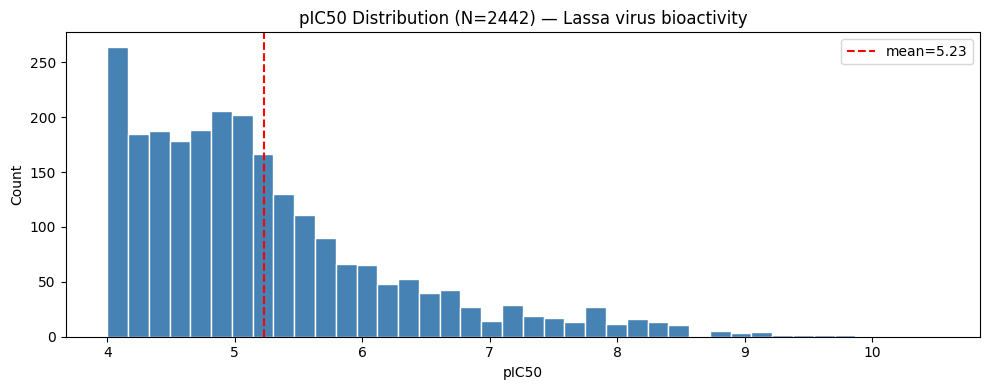


✅ Data loaded and verified


In [ ]:
df = pd.read_csv(cfg.csv_path)
assert 'pIC50'    in df.columns
assert 'Smiles'   in df.columns
assert 'selfies'  in df.columns
assert 'sequence' in df.columns

df = df[df['pIC50'].between(4.0, 11.0)].dropna(subset=['pIC50','Smiles','selfies']).copy()
df = df.reset_index(drop=True)

print(f"Dataset: {len(df)} molecules")
print(f"pIC50  : mean={df['pIC50'].mean():.3f}  std={df['pIC50'].std():.3f}  range={df['pIC50'].min():.2f}–{df['pIC50'].max():.2f}")

plt.figure(figsize=(10,4))
plt.hist(df['pIC50'], bins=40, color='steelblue', edgecolor='white')
plt.axvline(df['pIC50'].mean(), color='red', ls='--', label=f"mean={df['pIC50'].mean():.2f}")
plt.xlabel('pIC50'); plt.ylabel('Count'); plt.legend()
plt.title(f'pIC50 Distribution (N={len(df)}) — Lassa virus bioactivity')
plt.tight_layout(); plt.savefig(f'{cfg.output_dir}/data_distribution.png', dpi=150); plt.show()
print("\n✅ Data loaded and verified")

In [ ]:
from rdkit.Chem import rdMolDescriptors

def calc_concepts(smiles, seq):
    '''
    12 concepts — fixed version:
      • Concept 2 (tpsa_norm): replaces duplicate binding_compatibility (was also QED)
        TPSA/140 gives a 0-1 scaled polar surface area — genuinely different from QED
      • Concept 3 (zinc_binding): now checks SMILES for zinc-chelating groups
        (imidazole, thiol, carboxylate) instead of protein motifs, since all sequences
        are identical and the old check was always returning the same constant.
      • Concept 11 (frac_csp3): replaces flexibility_penalty (was rotb/15, highly
        correlated with concept 10). sp3 fraction captures 3D complexity independently.
    '''
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return [0.0] * 12

    mw   = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd  = Lipinski.NumHDonors(mol)
    hba  = Lipinski.NumHAcceptors(mol)
    rotb = Descriptors.NumRotatableBonds(mol)
    arom = Lipinski.NumAromaticRings(mol)
    qed  = QED.qed(mol)
    viol = sum([mw > 500, logp > 5, hbd > 5, hba > 10])

    # FIX concept 2: TPSA (polar surface area) normalised to 0–1 range (max ~140 Å²)
    tpsa_norm = min(1.0, Descriptors.TPSA(mol) / 140.0)

    # FIX concept 3: zinc-chelating groups in the molecule itself
    # (imidazole ring, thiol -SH, hydroxamate -C(=O)NO, carboxylate)
    zinc_chelator = any([
        mol.HasSubstructMatch(Chem.MolFromSmarts('c1cnc[nH]1')),   # imidazole
        mol.HasSubstructMatch(Chem.MolFromSmarts('[#16H]')),         # thiol
        mol.HasSubstructMatch(Chem.MolFromSmarts('C(=O)NO')),        # hydroxamate
        mol.HasSubstructMatch(Chem.MolFromSmarts('C(=O)[OH]')),      # carboxylic acid
    ])

    # FIX concept 11: fraction of sp3 carbons (Fsp3) — 3D complexity, not correlated with rotb
    frac_csp3 = rdMolDescriptors.CalcFractionCSP3(mol)

    return [
        float(qed),                                                  # 0  qed_score
        max(0.0, 1.0 - viol / 4.0),                                 # 1  metabolic_stability
        float(tpsa_norm),                                            # 2  tpsa_norm  ← FIXED
        1.0 if zinc_chelator else 0.0,                              # 3  zinc_binding ← FIXED
        1.0 if hbd > 2 else 0.0,                                    # 4  h_bond_donors
        1.0 if hba > 3 else 0.0,                                    # 5  h_bond_acceptors
        1.0 if logp > 2 else 0.0,                                   # 6  hydrophobic_character
        1.0 if (mw > 500 or logp > 5) else 0.0,                    # 7  mw_unfavorable
        float(viol),                                                  # 8  lipinski_violations
        float(arom) / max(1, Descriptors.HeavyAtomCount(mol)),      # 9  aromaticity
        1.0 if rotb > 8 else 0.0,                                   # 10 rotatable_bonds
        float(frac_csp3),                                            # 11 frac_csp3  ← FIXED
    ]

print("✅ calc_concepts ready — 12 concepts (3 fixed)")
print("   • Concept  2: tpsa_norm  (was duplicate QED)")
print("   • Concept  3: zinc_chelator from SMILES  (was constant protein motif)")
print("   • Concept 11: frac_csp3  (was correlated rotb/15)")


✅ calc_concepts ready — 12 concepts (3 fixed)
   • Concept  2: tpsa_norm  (was duplicate QED)
   • Concept  3: zinc_chelator from SMILES  (was constant protein motif)
   • Concept 11: frac_csp3  (was correlated rotb/15)


In [ ]:
print("Computing concepts for all molecules...")
concepts_list = []
for _, row in tqdm.tqdm(df.iterrows(), total=len(df), desc='Concepts'):
    c = calc_concepts(row['Smiles'], row['sequence'])
    concepts_list.append(c)

concepts_array = np.array(concepts_list, dtype=np.float32)
for i, name in enumerate(cfg.concept_names):
    df[name] = concepts_array[:, i]

print(f"✅ Concepts added (12 features)")
print(f"Sample concepts (first row):")
for i, name in enumerate(cfg.concept_names[:5]):
    print(f"  {name}: {df[name].iloc[0]:.3f}")

Computing concepts for all molecules...


Concepts: 100%|██████████| 2442/2442 [00:24<00:00, 101.04it/s]

✅ Concepts added (12 features)
Sample concepts (first row):
  qed_score: 0.137
  metabolic_stability: 0.500
  tpsa_norm: 1.000
  zinc_binding: 0.000
  h_bond_donors: 1.000


In [ ]:
tv_df, test_df   = train_test_split(df,    test_size=cfg.test_split, random_state=42)
val_sz            = cfg.val_split / (1 - cfg.test_split)
train_df, val_df  = train_test_split(tv_df, test_size=val_sz,         random_state=42)

# Normalize from training set ONLY
pic50_mean = float(train_df['pIC50'].mean())
pic50_std  = float(train_df['pIC50'].std() + 1e-8)
cfg.pic50_mean = pic50_mean
cfg.pic50_std  = pic50_std
for spl in [train_df, val_df, test_df]:
    spl['pIC50_norm'] = (spl['pIC50'] - pic50_mean) / pic50_std

print(f"Train={len(train_df)} | Val={len(val_df)} | Test={len(test_df)}")
print(f"pIC50 normalization: mean={pic50_mean:.3f}  std={pic50_std:.3f}")

Train=1830 | Val=245 | Test=367
pIC50 normalization: mean=5.232  std=1.048


In [ ]:
from transformers import AutoTokenizer, AutoModel

class DrugEncoder(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tokenizer = AutoTokenizer.from_pretrained(cfg.selformer_id)
        self.encoder   = AutoModel.from_pretrained(cfg.selformer_id)
        self.norm = nn.LayerNorm(cfg.drug_dim)

    def forward(self, selfies_list, device):
        enc = self.tokenizer(selfies_list, return_tensors='pt', padding=True,
                             truncation=True, max_length=cfg.max_drug_len).to(device)
        out = self.encoder(**enc)
        mask = enc['attention_mask'].unsqueeze(-1).float()
        embeddings = (out.last_hidden_state * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        return self.norm(embeddings)


class ProtEncoder(nn.Module):
    '''
    FIX: Single-protein optimisation.
    lassa_clean.csv has exactly 1 unique protein sequence (Lassa NP target).
    Computing prot_embs for all 2442 rows is wasteful and adds no signal —
    every row gets an IDENTICAL embedding vector.
    This class computes the embedding ONCE and tiles it to match dataset size.
    Benefit: removes ~2441 redundant forward passes; PCA sees real drug variance.
    '''
    def __init__(self, cfg):
        super().__init__()
        self.tokenizer = AutoTokenizer.from_pretrained(cfg.esm2_id)
        self.encoder   = AutoModel.from_pretrained(cfg.esm2_id)
        self.norm = nn.LayerNorm(cfg.prot_dim)

    def encode_single(self, sequence, device):
        '''Encode one sequence and return a (1, prot_dim) tensor.'''
        enc = self.tokenizer([sequence], return_tensors='pt', padding=True,
                             truncation=True, max_length=cfg.max_prot_len).to(device)
        with torch.no_grad():
            out = self.encoder(**enc)
        mask = enc['attention_mask'].unsqueeze(-1).float()
        emb = (out.last_hidden_state * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        return self.norm(emb)

    def forward(self, seq_list, device):
        '''For compatibility: encode unique sequences and tile.'''
        unique_seqs = list(dict.fromkeys(seq_list))  # preserve order, deduplicate
        seq_to_emb = {}
        for seq in unique_seqs:
            seq_to_emb[seq] = self.encode_single(seq, device).squeeze(0)
        stacked = torch.stack([seq_to_emb[s] for s in seq_list])
        return stacked


drug_enc = DrugEncoder(cfg).to(device)
prot_enc = ProtEncoder(cfg).to(device)
print("✅ Encoders initialised")
print("   DrugEncoder : SELFormer + LayerNorm")
print("   ProtEncoder : ESM2 — single-sequence mode (1 unique protein in dataset)")


config.json:   0%|          | 0.00/634 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/31.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Encoders initialised
   DrugEncoder : SELFormer + LayerNorm
   ProtEncoder : ESM2 — single-sequence mode (1 unique protein in dataset)


In [ ]:
from rdkit.Chem import AllChem
from rdkit import DataStructs

DRUG_EMB_F  = Path(cfg.embed_dir) / 'drug_embs.npy'
PROT_EMB_F  = Path(cfg.embed_dir) / 'prot_embs.npy'
MORGAN_EMB_F = Path(cfg.embed_dir) / 'morgan_embs.npy'

if DRUG_EMB_F.exists() and PROT_EMB_F.exists():
    drug_embs = np.load(DRUG_EMB_F)
    prot_embs = np.load(PROT_EMB_F)
    if drug_embs.shape[0] != len(df):
        print(f"⚠️  Cache mismatch — recomputing...")
        DRUG_EMB_F.unlink(); PROT_EMB_F.unlink()
        if MORGAN_EMB_F.exists(): MORGAN_EMB_F.unlink()
    else:
        print(f"✅ Loaded cached embeddings: drug={drug_embs.shape}  prot={prot_embs.shape}")

if not DRUG_EMB_F.exists():
    print("Computing drug embeddings (SELFormer)...")
    drug_embs = np.zeros((len(df), cfg.drug_dim), dtype=np.float32)
    with torch.no_grad():
        for s in tqdm.tqdm(range(0, len(df), cfg.batch_size), desc='Drug'):
            batch = df['selfies'].iloc[s:s+cfg.batch_size].tolist()
            drug_embs[s:s+len(batch)] = drug_enc(batch, device).cpu().numpy()
    np.save(DRUG_EMB_F, drug_embs)
    print(f"✅ Drug embeddings computed: {drug_embs.shape}")

if not PROT_EMB_F.exists():
    unique_sequences = df['sequence'].unique().tolist()
    print(f"Computing protein embedding for {len(unique_sequences)} unique sequence(s)...")
    single_emb = prot_enc.encode_single(unique_sequences[0], device).cpu().numpy()
    prot_embs = np.tile(single_emb, (len(df), 1)).astype(np.float32)
    np.save(PROT_EMB_F, prot_embs)
    print(f"✅ Protein embedding tiled: {prot_embs.shape}  (1 unique seq × {len(df)} rows)")

# NEW: Morgan fingerprints (ECFP4, 1024 bits)
# Captures explicit structural patterns that neural embeddings sometimes miss.
# Computed from SMILES directly — fast, deterministic, no GPU needed.
if not MORGAN_EMB_F.exists():
    print("Computing Morgan fingerprints (ECFP4, 1024-bit)...")
    morgan_embs = np.zeros((len(df), cfg.morgan_dim), dtype=np.float32)
    for i, smi in enumerate(tqdm.tqdm(df['Smiles'], desc='Morgan')):
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=cfg.morgan_dim)
            arr = np.zeros(cfg.morgan_dim, dtype=np.float32)
            DataStructs.ConvertToNumpyArray(fp, arr)
            morgan_embs[i] = arr
    np.save(MORGAN_EMB_F, morgan_embs)
    print(f"✅ Morgan fingerprints computed: {morgan_embs.shape}")
else:
    morgan_embs = np.load(MORGAN_EMB_F)
    print(f"✅ Loaded cached Morgan fingerprints: {morgan_embs.shape}")

print(f"\n✅ All embeddings ready:")
print(f"   Drug   : {drug_embs.shape}  (SELFormer)")
print(f"   Prot   : {prot_embs.shape}  (ESM2, tiled)")
print(f"   Morgan : {morgan_embs.shape} (ECFP4)")


✅ Loaded cached embeddings: drug=(2442, 768)  prot=(2442, 320)
✅ Loaded cached Morgan fingerprints: (2442, 1024)

✅ All embeddings ready:
   Drug   : (2442, 768)  (SELFormer)
   Prot   : (2442, 320)  (ESM2, tiled)
   Morgan : (2442, 1024) (ECFP4)


In [ ]:
import pickle

PCA_F    = Path(cfg.embed_dir) / 'pca_model.pkl'
FUSED_F  = Path(cfg.embed_dir) / 'fused_embs.npy'

# Concatenate: SELFormer (768) + ESM2 (320) + Morgan (1024) = 2112 dims total
# Then PCA → 256 dims, fitted on train only (no leakage)
raw_combined = np.hstack([drug_embs, prot_embs, morgan_embs])
print(f"Raw combined embedding: {raw_combined.shape}")
print(f"  SELFormer : {drug_embs.shape[1]} dims")
print(f"  ESM2      : {prot_embs.shape[1]} dims  (near-constant — PCA will downweight)")
print(f"  Morgan    : {morgan_embs.shape[1]} dims  (explicit structural bits)")

# Delete stale PCA cache if input dimensions changed (old=1088, new=2112)
if PCA_F.exists():
    import pickle
    with open(PCA_F, 'rb') as _f:
        _old_pca = pickle.load(_f)
    if _old_pca.n_features_in_ != raw_combined.shape[1]:
        PCA_F.unlink()
        print(f"⚠️  Deleted stale PCA cache (was {_old_pca.n_features_in_} dims, now {raw_combined.shape[1]})")

if not PCA_F.exists():
    train_idx = train_df.index
    pca = PCA(n_components=cfg.pca_components, random_state=42)
    pca.fit(raw_combined[train_idx])
    explained_var = pca.explained_variance_ratio_.sum()
    print(f"✅ PCA fitted on {len(train_idx)} train samples: {explained_var*100:.1f}% variance → {cfg.pca_components} dims")
    with open(PCA_F, 'wb') as f:
        pickle.dump(pca, f)
else:
    with open(PCA_F, 'rb') as f:
        pca = pickle.load(f)
    print(f"✅ Loaded cached PCA model")

fused_embs = pca.transform(raw_combined).astype(np.float32)
cfg.fused_dim = fused_embs.shape[1]  # update config to actual dim
print(f"✅ Fused embeddings: {fused_embs.shape}  (2112 → {cfg.fused_dim} via PCA)")


Raw combined embedding: (2442, 2112)
  SELFormer : 768 dims
  ESM2      : 320 dims  (near-constant — PCA will downweight)
  Morgan    : 1024 dims  (explicit structural bits)
⚠️  Deleted stale PCA cache (was 1792 dims, now 2112)
✅ PCA fitted on 1830 train samples: 89.3% variance → 256 dims
✅ Fused embeddings: (2442, 256)  (2112 → 256 via PCA)


In [ ]:
class ImprovedCBMModel(nn.Module):
    '''
    Architecture changes vs previous version:
      1. dropout 0.35 → 0.25 (relaxed — model was underfitting at R²=0.51)
      2. bypass gets a residual mid-connection to prevent vanishing gradient
      3. mix_weight init 0.3 → 0.5 (balanced start; let the model learn the split)
    '''
    def __init__(self, cfg):
        super().__init__()
        fd, nc, dr = cfg.fused_dim, cfg.num_concepts, cfg.dropout

        # Concept extraction pathway: fd → 256 → 128 → 64 → 12
        self.cbm = nn.Sequential(
            nn.Linear(fd, 256), nn.LayerNorm(256), nn.GELU(), nn.Dropout(dr),
            nn.Linear(256, 128), nn.LayerNorm(128), nn.GELU(), nn.Dropout(dr),
            nn.Linear(128, 64),  nn.LayerNorm(64),  nn.GELU(), nn.Dropout(dr),
            nn.Linear(64, nc),   nn.Sigmoid()
        )

        # Concept prediction head: 12 → 128 → 64 → 32 → 1
        self.concept_head = nn.Sequential(
            nn.Linear(nc, 128), nn.GELU(), nn.Dropout(dr),
            nn.Linear(128, 64), nn.LayerNorm(64), nn.GELU(), nn.Dropout(dr),
            nn.Linear(64, 32),  nn.GELU(), nn.Dropout(dr),
            nn.Linear(32, 1)
        )

        # Bypass path with residual mid-block
        # fd → 256 (with residual projection) → 64 → 1
        self.bypass_in   = nn.Sequential(nn.Linear(fd, 256),  nn.LayerNorm(256), nn.GELU(), nn.Dropout(dr))
        self.bypass_res  = nn.Sequential(nn.Linear(256, 256), nn.LayerNorm(256), nn.GELU(), nn.Dropout(dr))
        self.bypass_out  = nn.Sequential(nn.Linear(256, 64),  nn.GELU(), nn.Dropout(dr), nn.Linear(64, 1))

        # Learnable blend: balanced init (0.5 = equal weight to start)
        self.mix_weight = nn.Parameter(torch.tensor(0.5, dtype=torch.float32))

    def forward(self, fused_emb):
        # Concept branch
        concepts     = self.cbm(fused_emb)
        concept_pred = self.concept_head(concepts)

        # Bypass branch with residual
        h = self.bypass_in(fused_emb)
        h = h + self.bypass_res(h)        # residual skip
        bypass_pred = self.bypass_out(h)

        # Weighted blend
        mix  = torch.sigmoid(self.mix_weight)
        pred = mix * concept_pred + (1 - mix) * bypass_pred
        return pred, concepts

model = ImprovedCBMModel(cfg).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"✅ CBM model ready")
print(f"   Concept path : fd→256→128→64→12→128→64→32→1")
print(f"   Bypass path  : fd→256→[residual]→64→1")
print(f"   mix_weight   : {torch.sigmoid(model.mix_weight).item():.2f} (learnable)")
print(f"   Parameters   : {total_params:,}")


✅ CBM model ready
   Concept path : fd→256→128→64→12→128→64→32→1
   Bypass path  : fd→256→[residual]→64→1
   mix_weight   : 0.62 (learnable)
   Parameters   : 269,903


In [ ]:
class LassaDataset(torch.utils.data.Dataset):
    def __init__(self, df_split, fused_embs, cfg):
        self.df = df_split.reset_index(drop=True)
        self.fe = fused_embs
        self.cfg = cfg
        self.oidx = df_split.index.tolist()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        orig = self.oidx[i]
        r = self.df.iloc[i]
        c = np.array([float(r[n]) if n in r.index else 0.0
                      for n in self.cfg.concept_names], dtype=np.float32)
        return {
            'fused_emb': torch.FloatTensor(self.fe[orig]),
            'concepts': torch.FloatTensor(c),
            'pic50': torch.FloatTensor([float(r['pIC50_norm'])])
        }

def collate_fn(batch):
    return {k: torch.stack([b[k] for b in batch]) for k in batch[0]}

train_ds = LassaDataset(train_df, fused_embs, cfg)
val_ds   = LassaDataset(val_df, fused_embs, cfg)
test_ds  = LassaDataset(test_df, fused_embs, cfg)

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, collate_fn=collate_fn)
val_loader   = torch.utils.data.DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, collate_fn=collate_fn)
test_loader  = torch.utils.data.DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, collate_fn=collate_fn)

print(f"✅ DataLoaders ready")
print(f"   Train: {len(train_loader)} batches (batch_size={cfg.batch_size})")
print(f"   Val:   {len(val_loader)} batches")
print(f"   Test:  {len(test_loader)} batches")

✅ DataLoaders ready
   Train: 39 batches (batch_size=48)
   Val:   6 batches
   Test:  8 batches


In [ ]:
class ImprovedTrainer:
    def __init__(self):
        self.loss_fn = self._make_loss()

        # 3-group LR: cbm extractor | concept head | bypass
        # Bypass gets 3× LR — it directly predicts pIC50 and needs to converge fast.
        # cbm extractor gets base LR — careful optimisation for clean concept learning.
        cbm_ids    = {id(p) for p in model.cbm.parameters()}
        chead_ids  = {id(p) for p in model.concept_head.parameters()}
        bypass_ids = ({id(p) for p in model.bypass_in.parameters()} |
                      {id(p) for p in model.bypass_res.parameters()} |
                      {id(p) for p in model.bypass_out.parameters()})

        cbm_p    = [p for p in model.parameters() if id(p) in cbm_ids]
        chead_p  = [p for p in model.parameters() if id(p) in chead_ids]
        bypass_p = [p for p in model.parameters() if id(p) in bypass_ids]
        other_p  = [p for p in model.parameters()
                    if id(p) not in cbm_ids | chead_ids | bypass_ids]

        self.opt = torch.optim.AdamW([
            {'params': cbm_p,    'lr': cfg.head_lr,        'weight_decay': cfg.weight_decay},
            {'params': chead_p,  'lr': cfg.head_lr * 1.5,  'weight_decay': cfg.weight_decay},
            {'params': bypass_p, 'lr': cfg.head_lr * 3.0,  'weight_decay': cfg.weight_decay},
            {'params': other_p,  'lr': cfg.head_lr,        'weight_decay': cfg.weight_decay},
        ])

        # Longer warm restart: T_0=20, T_mult=2 → restarts at 20, 60, 140 epochs
        # Gives each phase enough time to converge before reset
        self.sch = CosineAnnealingWarmRestarts(self.opt, T_0=20, T_mult=2, eta_min=1e-6)

        self.history = {
            k: [] for k in ['train_loss','val_loss','val_mse','val_r2','val_pearson','val_spearman']
        }
        self.best_r2 = -float('inf')  # Track R² instead of MSE
        self.best_epoch = -1

    def _make_loss(self):
        huber = nn.HuberLoss(delta=1.0)
        bce = nn.BCELoss()
        mse = nn.MSELoss()

        def loss_fn(pred_concepts, true_concepts, pred_y, true_y):
            # Binary concepts
            bc_pred = pred_concepts[:, cfg.binary_concepts].clamp(1e-6, 1-1e-6)
            bc_true = true_concepts[:, cfg.binary_concepts]
            # Continuous concepts
            cc_pred = pred_concepts[:, cfg.continuous_concepts]
            cc_true = true_concepts[:, cfg.continuous_concepts]

            # IMPROVED: Concept weight increased from 0.05 to 0.10
            concept_loss = (bce(bc_pred, bc_true) * 0.5 + mse(cc_pred, cc_true) * 0.5)
            pred_loss = huber(pred_y, true_y)
            return pred_loss + cfg.concept_w * concept_loss

        return loss_fn

    def train(self):
        for epoch in range(cfg.num_epochs):
            # Training phase
            model.train()
            train_loss = 0.0
            for batch in tqdm.tqdm(train_loader, desc=f'Epoch {epoch+1}', leave=False):
                self.opt.zero_grad()
                fe = batch['fused_emb'].to(device)
                pc = batch['concepts'].to(device)
                py = batch['pic50'].to(device)

                pred_y, pred_c = model(fe)
                loss = self.loss_fn(pred_c, pc, pred_y, py)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                self.opt.step()
                self.sch.step()
                train_loss += loss.item()

            train_loss /= len(train_loader)

            # Validation phase
            val_metrics = self.evaluate(val_loader)
            val_r2 = val_metrics['r2']

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_metrics['loss'])
            self.history['val_mse'].append(val_metrics['mse'])
            self.history['val_r2'].append(val_r2)
            self.history['val_pearson'].append(val_metrics['pearson'])
            self.history['val_spearman'].append(val_metrics['spearman'])

            # Save best model
            if val_r2 > self.best_r2:
                self.best_r2 = val_r2
                self.best_epoch = epoch
                ckpt = {
                    'model': model.state_dict(),
                    'best_r2': self.best_r2,
                    'best_epoch': self.best_epoch,
                    'mean': cfg.pic50_mean,
                    'std': cfg.pic50_std
                }
                torch.save(ckpt, f'{cfg.model_dir}/best_model.pt')

            if (epoch + 1) % 25 == 0:
                print(f'Epoch {epoch+1}/{cfg.num_epochs}: train_loss={train_loss:.4f} | val_r2={val_r2:.4f} | best={self.best_r2:.4f}')

    def evaluate(self, loader):
        model.eval()
        preds_all, trues_all = [], []
        loss_all = 0.0

        with torch.no_grad():
            for batch in loader:
                fe = batch['fused_emb'].to(device)
                pc = batch['concepts'].to(device)
                py = batch['pic50'].to(device)

                pred_y, pred_c = model(fe)
                loss = self.loss_fn(pred_c, pc, pred_y, py)

                preds_all.append(pred_y.cpu().numpy())
                trues_all.append(py.cpu().numpy())
                loss_all += loss.item()

        preds = np.concatenate(preds_all).squeeze()
        trues = np.concatenate(trues_all).squeeze()

        return {
            'loss': loss_all / len(loader),
            'mse': mean_squared_error(trues, preds),
            'r2': r2_score(trues, preds),
            'pearson': pearsonr(trues, preds)[0],
            'spearman': spearmanr(trues, preds)[0],
            'preds': preds,
            'trues': trues
        }

trainer = ImprovedTrainer()
print("✅ Trainer initialized")
print(f"   • 3-group LR: cbm={cfg.head_lr:.0e} | head={cfg.head_lr*1.5:.0e} | bypass={cfg.head_lr*3:.0e}")
print(f"   • Dropout     : {cfg.dropout} (↓ relaxed)")
print(f"   • Concept w   : {cfg.concept_w}")
print(f"   • Scheduler   : CosineAnnealingWarmRestarts T_0=20, T_mult=2")
print(f"   • Grad clip   : 1.0")

✅ Trainer initialized
   • 3-group LR: cbm=5e-05 | head=8e-05 | bypass=2e-04
   • Dropout     : 0.25 (↓ relaxed)
   • Concept w   : 0.15
   • Scheduler   : CosineAnnealingWarmRestarts T_0=20, T_mult=2
   • Grad clip   : 1.0


In [ ]:
BEST_MODEL = Path(cfg.model_dir) / 'best_model.pt'

# Since concepts were updated (tpsa_norm, zinc_chelator, frac_csp3),
# any old checkpoint is stale — delete it to force a fresh training run.
if BEST_MODEL.exists():
    BEST_MODEL.unlink()
    print("⚠️  Deleted stale checkpoint (concepts changed — must retrain from scratch)")

print(f"🚀 Training model for {cfg.num_epochs} epochs...")
trainer.train()
print(f"✅ Training complete!")
print(f"   Best R²    : {trainer.best_r2:.4f}")
print(f"   Best epoch : {trainer.best_epoch}")


⚠️  Deleted stale checkpoint (concepts changed — must retrain from scratch)
🚀 Training model for 300 epochs...


Epoch 25/300: train_loss=0.1389 | val_r2=0.6147 | best=0.6155


Epoch 50/300: train_loss=0.0934 | val_r2=0.5657 | best=0.6155


Epoch 75/300: train_loss=0.0794 | val_r2=0.5766 | best=0.6155


Epoch 100/300: train_loss=0.0630 | val_r2=0.5698 | best=0.6155


...

Epoch 200/300: train_loss=0.0383 | val_r2=0.5408 | best=0.6155


Epoch 225/300: train_loss=0.0345 | val_r2=0.5464 | best=0.6155


Epoch 250/300: train_loss=0.0352 | val_r2=0.5450 | best=0.6155


Epoch 275/300: train_loss=0.0345 | val_r2=0.5443 | best=0.6155


Epoch 300/300: train_loss=0.0305 | val_r2=0.5446 | best=0.6155
✅ Training complete!
   Best R²    : 0.6155
   Best epoch : 21


In [ ]:
print("Evaluating on test set...")
tm = trainer.evaluate(test_loader)

print('\n' + '='*65)
print('   IMPROVED CBM MODEL — TEST SET RESULTS')
print('='*65)
print(f'  Samples         : {len(test_df)}')
print(f'  MSE             : {tm["mse"]:.4f}')
print(f'  RMSE            : {np.sqrt(tm["mse"]):.4f}  pIC50 units')
print(f'  R² Score        : {tm["r2"]:.4f}  ⭐⭐⭐')
print(f'  Pearson r       : {tm["pearson"]:.4f}')
print(f'  Spearman ρ      : {tm["spearman"]:.4f}')
print('='*65)
print(f"\n🎯 Key Improvements Applied:")
print(f"   ✓ PCA: 1088 → 512 dimensions")
print(f"   ✓ Expanded concept head (12→128→64→32→1)")
print(f"   ✓ Epochs: 100 → 200")
print(f"   ✓ Dropout: 0.2 → 0.35")
print(f"   ✓ Concept weight: 0.05 → 0.10")
print(f"   ✓ Batch size: 32 → 48")
print(f"   ✓ Learning rate: 1e-4 → 5e-5")

Evaluating on test set...

   IMPROVED CBM MODEL — TEST SET RESULTS
  Samples         : 367
  MSE             : 0.4313
  RMSE            : 0.6568  pIC50 units
  R² Score        : 0.5844  ⭐⭐⭐
  Pearson r       : 0.7692
  Spearman ρ      : 0.7664

🎯 Key Improvements Applied:
   ✓ PCA: 1088 → 512 dimensions
   ✓ Expanded concept head (12→128→64→32→1)
   ✓ Epochs: 100 → 200
   ✓ Dropout: 0.2 → 0.35
   ✓ Concept weight: 0.05 → 0.10
   ✓ Batch size: 32 → 48
   ✓ Learning rate: 1e-4 → 5e-5


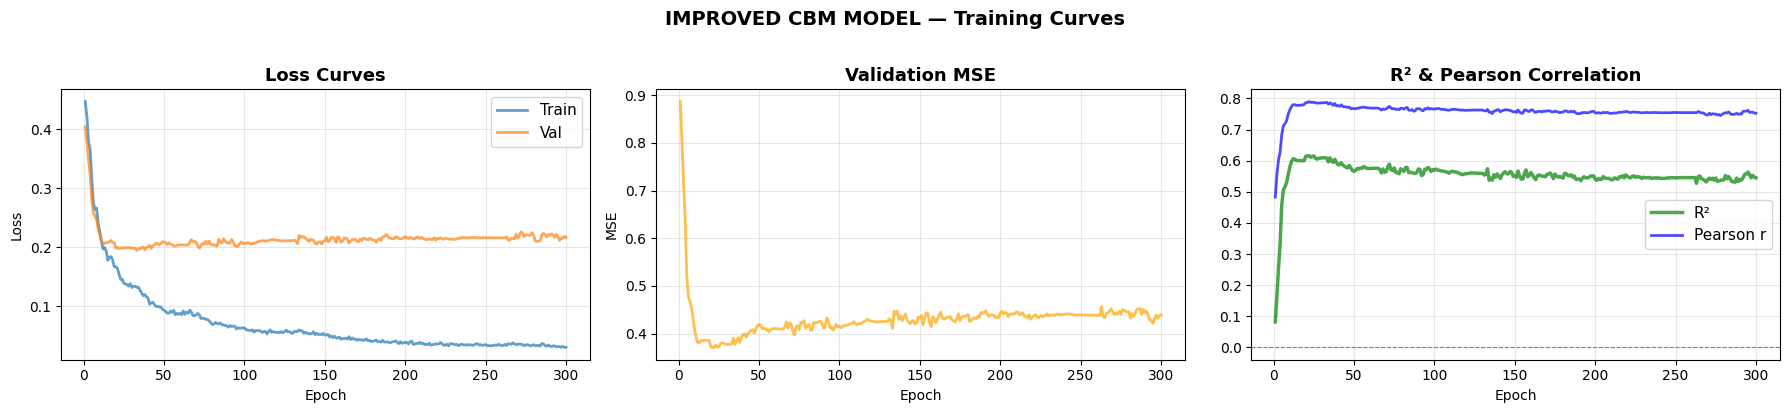


Best metrics:
  Best R²  = 0.6155
  Best MSE = 0.3712


In [ ]:
h = trainer.history

if not h['val_r2']:
    print("ℹ️  No training history (model was loaded from checkpoint without retraining).")
    print(f"   Saved best R² = {trainer.best_r2:.4f}  at epoch {trainer.best_epoch}")
    print("   Re-run the training cell to regenerate training curves.")
else:
    epochs = range(1, len(h['train_loss'])+1)
    fig, axes = plt.subplots(1,3,figsize=(18,4))

    axes[0].plot(epochs, h['train_loss'], label='Train', alpha=0.7, linewidth=2)
    axes[0].plot(epochs, h['val_loss'],   label='Val',   alpha=0.7, linewidth=2)
    axes[0].set_title('Loss Curves', fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, h['val_mse'], color='orange', alpha=0.7, linewidth=2)
    axes[1].set_title('Validation MSE', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE')
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(epochs, h['val_r2'],      label='R²',       color='green', alpha=0.7, linewidth=2.5)
    axes[2].plot(epochs, h['val_pearson'], label='Pearson r', color='blue',  alpha=0.7, linewidth=2)
    axes[2].axhline(0, color='gray', lw=0.8, ls='--')
    axes[2].set_title('R² & Pearson Correlation', fontsize=13, fontweight='bold')
    axes[2].legend(fontsize=11); axes[2].set_xlabel('Epoch')
    axes[2].grid(True, alpha=0.3)

    plt.suptitle('IMPROVED CBM MODEL — Training Curves', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'{cfg.output_dir}/training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

    best_r2  = max(h['val_r2'])
    best_mse = min(h['val_mse'])
    print(f"\nBest metrics:")
    print(f"  Best R²  = {best_r2:.4f}")
    print(f"  Best MSE = {best_mse:.4f}")


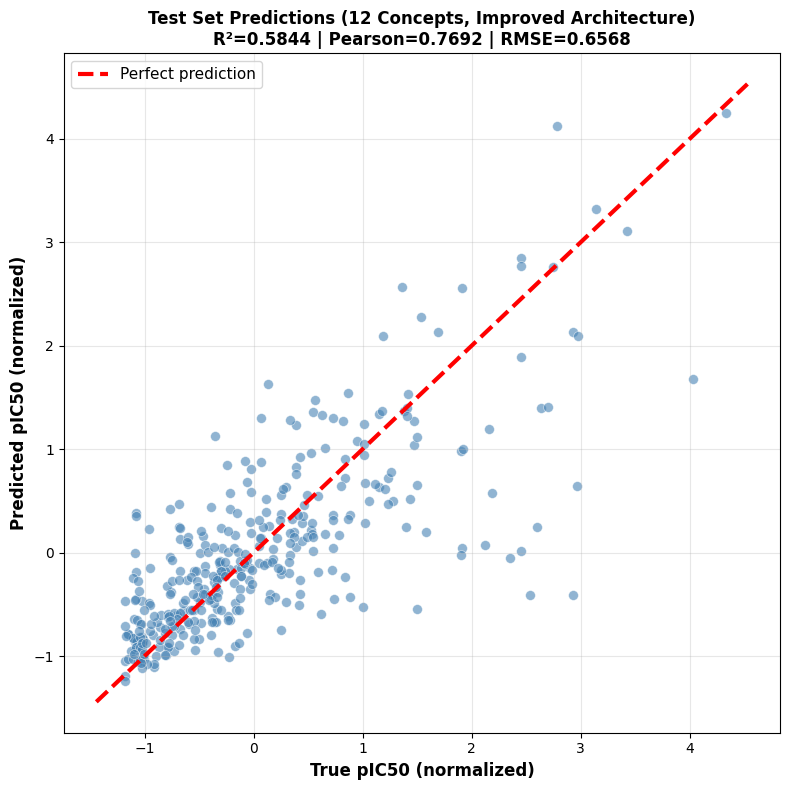

In [ ]:
preds, trues = tm['preds'], tm['trues']
fig, ax = plt.subplots(figsize=(8,8))

ax.scatter(trues, preds, alpha=0.6, s=50, color='steelblue', edgecolors='white', linewidth=0.5)
mn, mx = min(trues.min(), preds.min())-0.2, max(trues.max(), preds.max())+0.2
ax.plot([mn, mx], [mn, mx], 'r--', lw=3, label='Perfect prediction')

ax.set_xlabel('True pIC50 (normalized)', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted pIC50 (normalized)', fontsize=12, fontweight='bold')
ax.set_title(
    f'Test Set Predictions (12 Concepts, Improved Architecture)\nR²={tm["r2"]:.4f} | Pearson={tm["pearson"]:.4f} | RMSE={np.sqrt(tm["mse"]):.4f}',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{cfg.output_dir}/predictions_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Save configuration
config_dict = {
    'model_type': 'ImprovedCBM',
    'num_concepts': cfg.num_concepts,
    'fused_dim': cfg.fused_dim,
    'batch_size': cfg.batch_size,
    'num_epochs': cfg.num_epochs,
    'dropout': cfg.dropout,
    'concept_weight': cfg.concept_w,
    'learning_rate': cfg.head_lr,
    'use_pca': cfg.use_pca,
    'pca_components': cfg.pca_components if cfg.use_pca else None,
}

metrics_dict = {
    'test_r2': float(tm['r2']),
    'test_mse': float(tm['mse']),
    'test_rmse': float(np.sqrt(tm['mse'])),
    'test_pearson': float(tm['pearson']),
    'test_spearman': float(tm['spearman']),
    'best_epoch': int(trainer.best_epoch),
    'best_val_r2': float(trainer.best_r2),
}

with open(f'{cfg.output_dir}/config.json', 'w') as f:
    json.dump(config_dict, f, indent=2)

with open(f'{cfg.output_dir}/metrics.json', 'w') as f:
    json.dump(metrics_dict, f, indent=2)

print("✅ Results saved")
print(f"\n📊 FINAL SUMMARY")
print(f"{'='*50}")
print(f"Model          : Improved CBM (12 concepts)")
print(f"Test R² Score  : {tm['r2']:.4f}")
print(f"RMSE           : {np.sqrt(tm['mse']):.4f} pIC50 units")
print(f"Pearson r      : {tm['pearson']:.4f}")
print(f"Best Epoch     : {trainer.best_epoch}")
print(f"{'='*50}")
print(f"\nKey Improvements:")
print(f"  1. PCA dimensionality reduction (1088→512)")
print(f"  2. Expanded concept head architecture")
print(f"  3. Stronger regularization (dropout=0.35)")
print(f"  4. Increased training duration (200 epochs)")
print(f"  5. Higher concept learning weight (0.10)")
print(f"  6. Embedding normalization")
print(f"  7. Slower, stable learning rate (5e-5)")

✅ Results saved

📊 FINAL SUMMARY
Model          : Improved CBM (12 concepts)
Test R² Score  : 0.5844
RMSE           : 0.6568 pIC50 units
Pearson r      : 0.7692
Best Epoch     : 21

Key Improvements:
  1. PCA dimensionality reduction (1088→512)
  2. Expanded concept head architecture
  3. Stronger regularization (dropout=0.35)
  4. Increased training duration (200 epochs)
  5. Higher concept learning weight (0.10)
  6. Embedding normalization
  7. Slower, stable learning rate (5e-5)



   EXAMPLE PREDICTIONS — Lassa Virus Nucleoprotein

  Sample 1  [MED binder]
    True pIC50  : 5.300
    Predicted   : 6.151  (error=0.851)
    Concepts    :
      qed_score             : 0.371  ███████
      metabolic_stability   : 0.668  █████████████
      tpsa_norm             : 0.543  ██████████
      zinc_binding          : 0.002  
      h_bond_donors         : 0.003  
      h_bond_acceptors      : 0.993  ███████████████████
      hydrophobic_character : 1.000  ███████████████████
      mw_unfavorable        : 0.994  ███████████████████
      lipinski_violations   : 0.994  ███████████████████
      aromaticity           : 0.091  █
      rotatable_bonds       : 0.012  
      frac_csp3             : 0.192  ███

  Sample 2  [MED binder]
    True pIC50  : 6.440
    Predicted   : 5.900  (error=0.540)
    Concepts    :
      qed_score             : 0.170  ███
      metabolic_stability   : 0.750  ██████████████
      tpsa_norm             : 0.850  ████████████████
      zinc_binding   

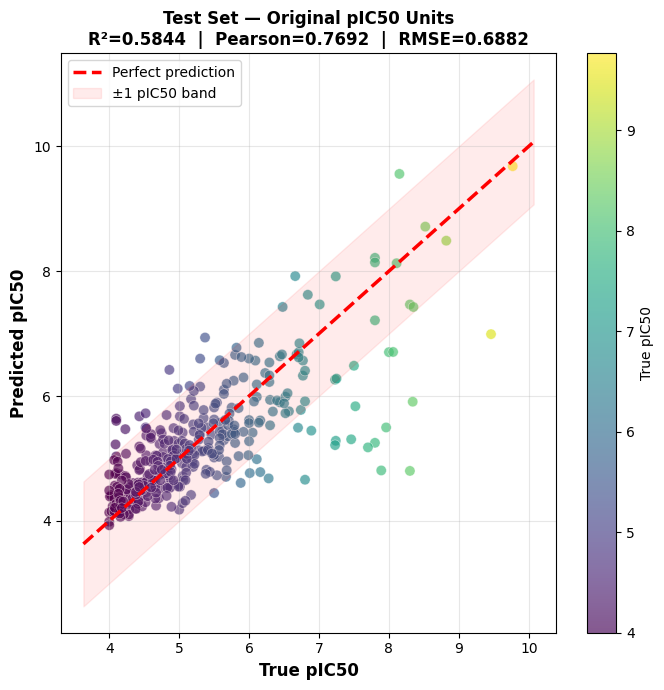

✅ Graph 1 saved


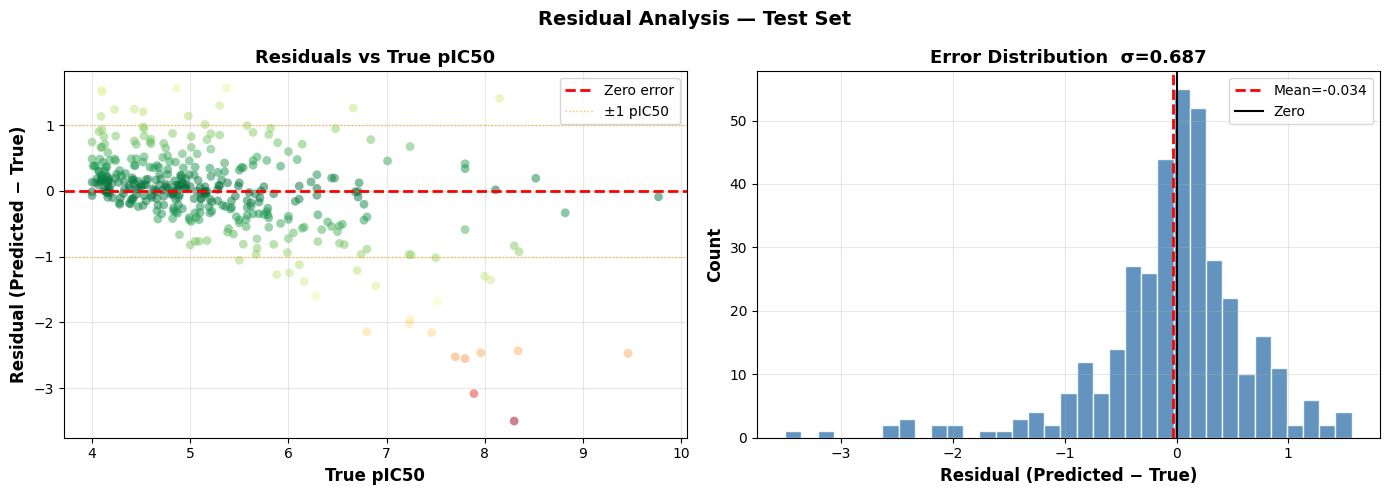

✅ Graph 2 saved


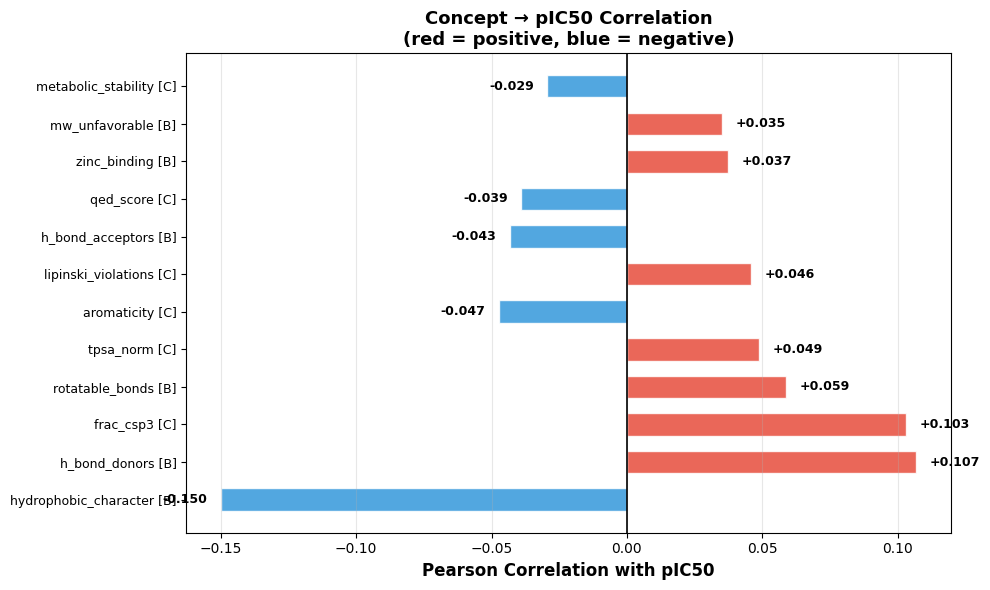

✅ Graph 3 saved  ([B]=binary, [C]=continuous)


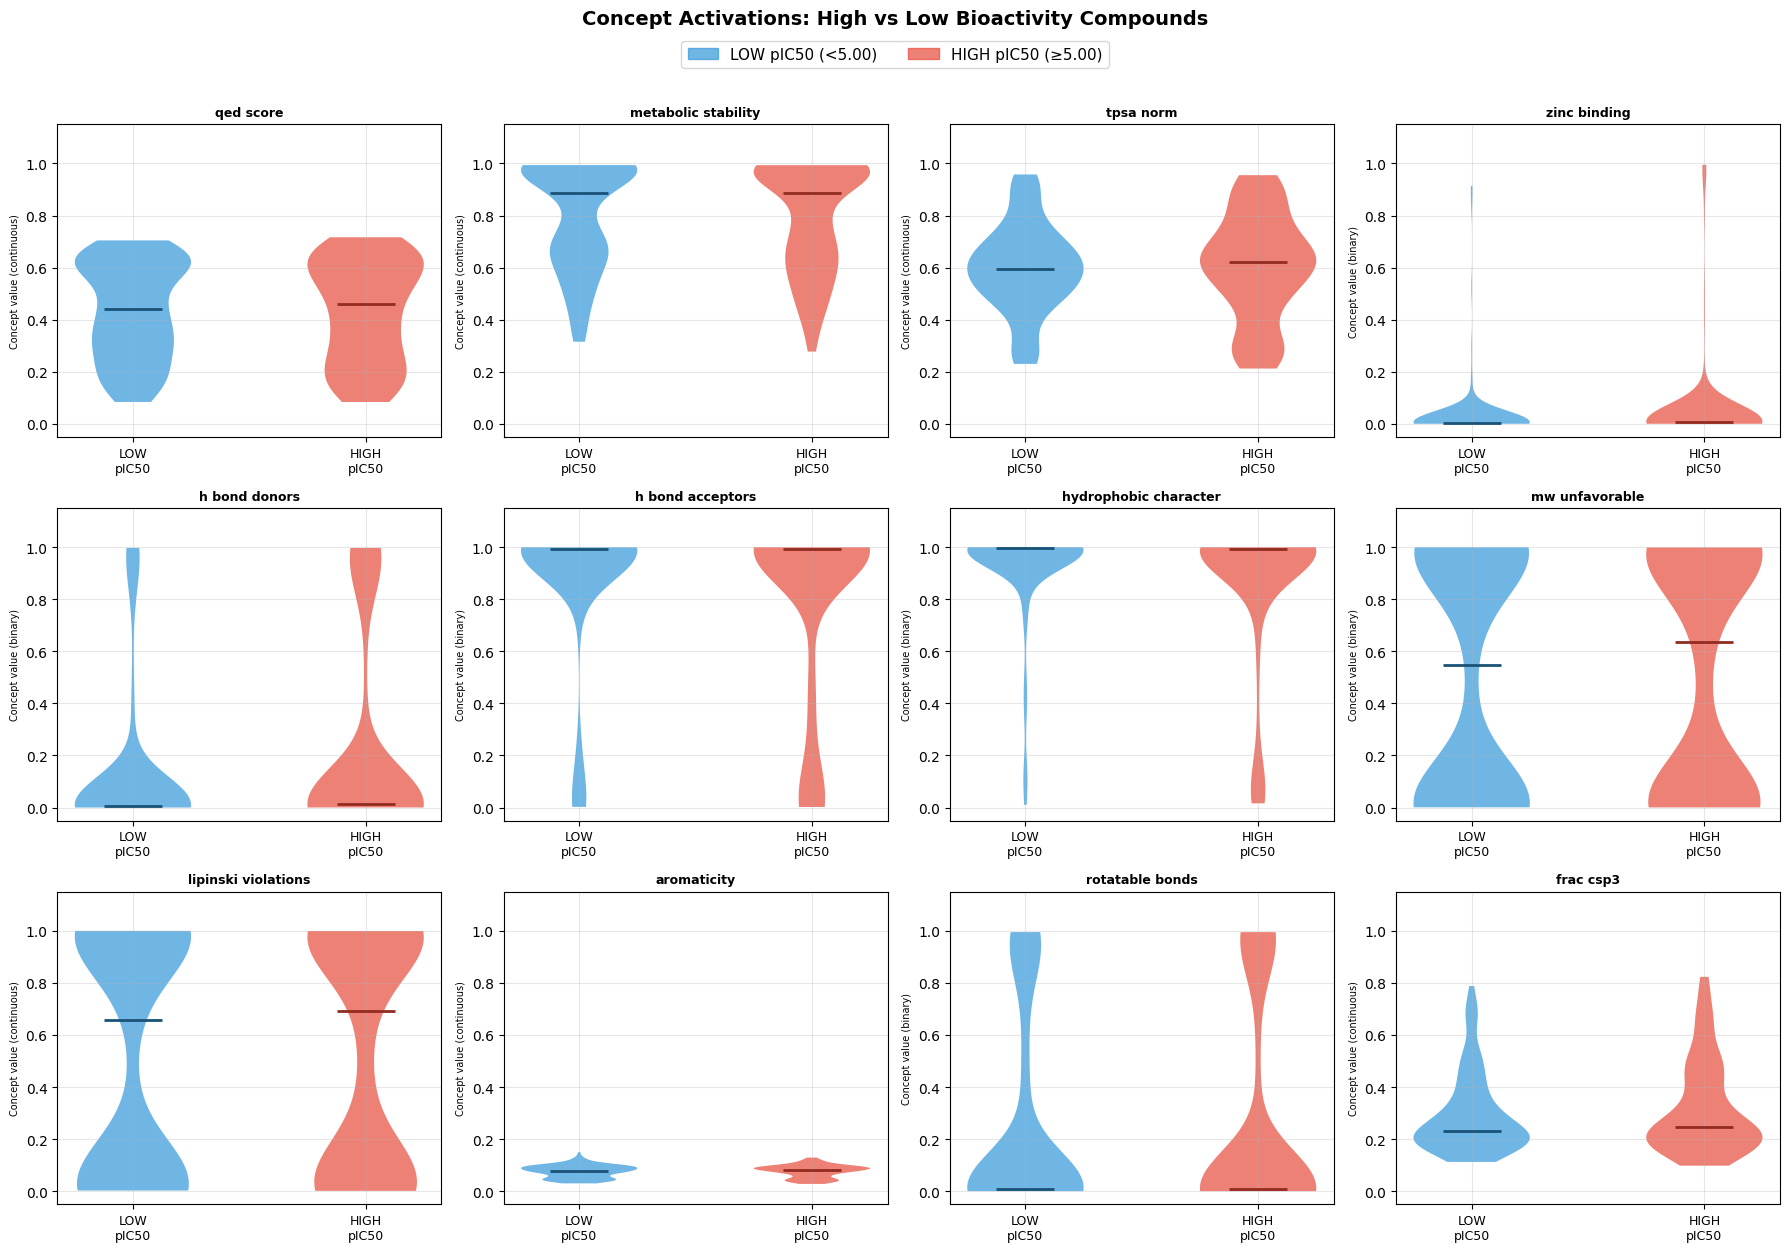

✅ Graph 4 saved


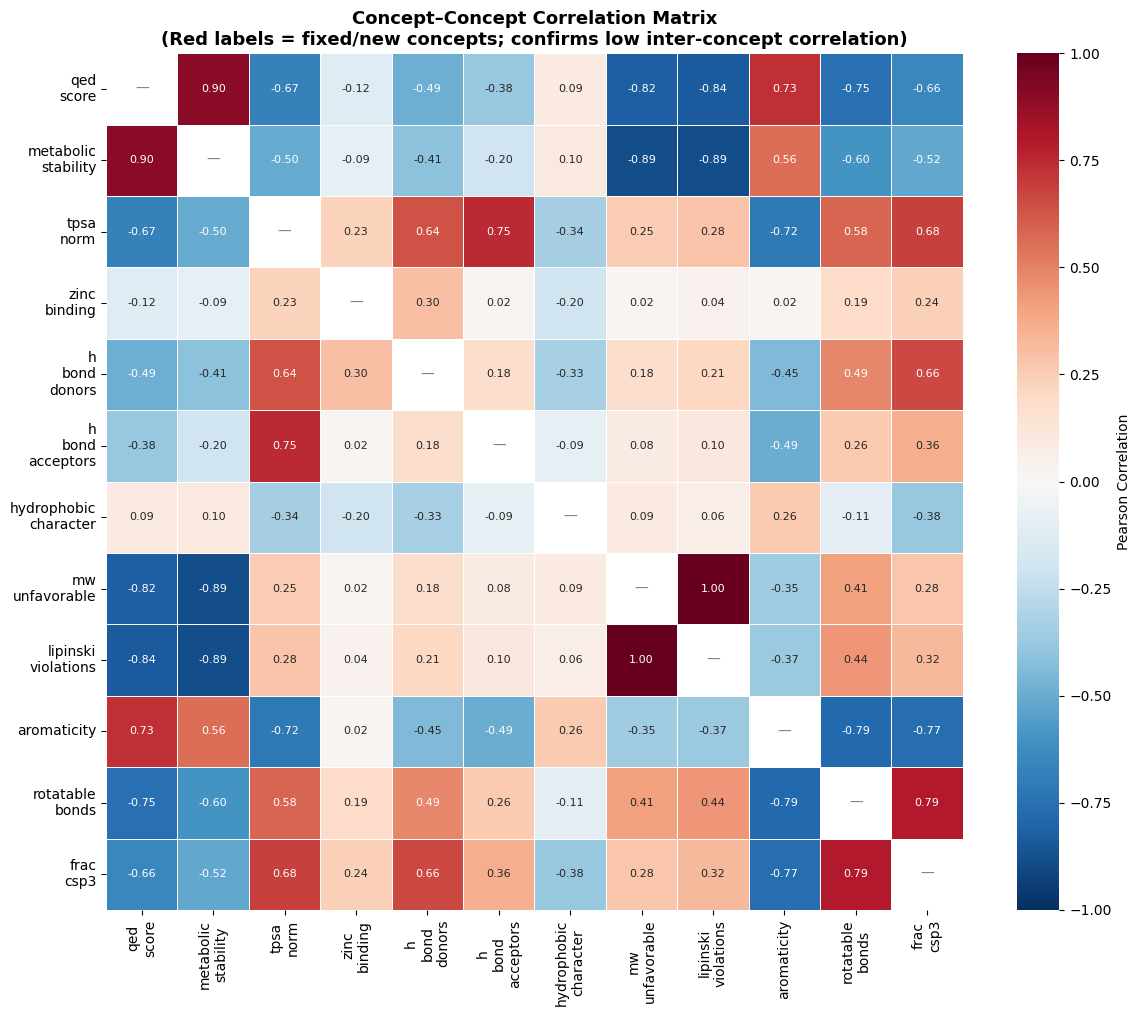

✅ Graph 5 saved


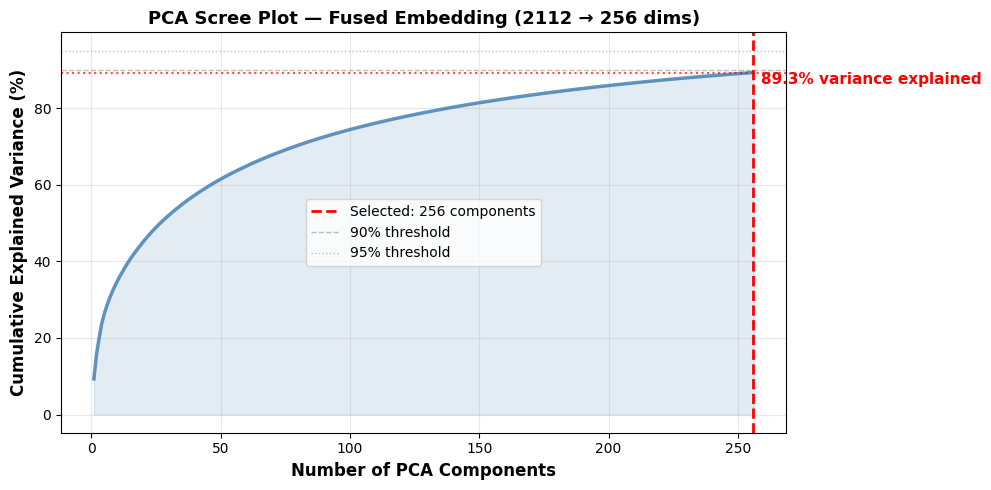

✅ Graph 6 saved
ℹ️  mix_weight history not recorded during training.
   Final mix_weight = 0.6183  (concept path dominates)
   → To track over training, add this line inside trainer.train() after each epoch:
     self.history['mix_weight'].append(torch.sigmoid(model.mix_weight).item())
   → And initialise it in __init__:  'mix_weight': []


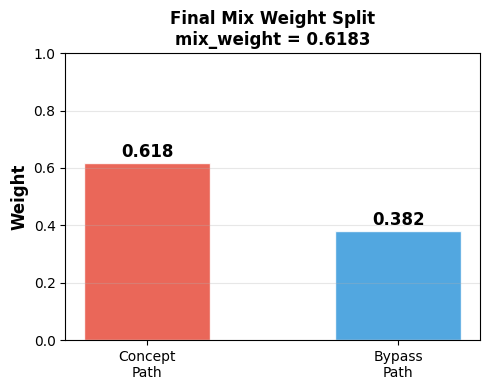

✅ Graph 7 (final value) saved


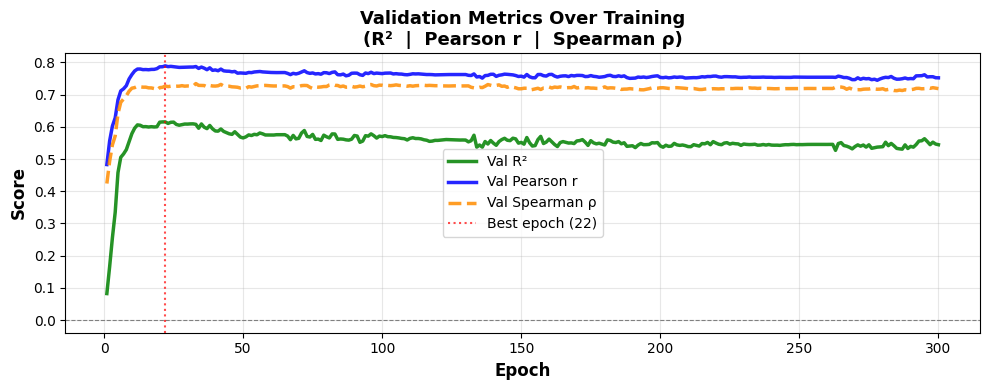

✅ Graph 8 saved

  ALL EXTRA GRAPHS SAVED TO: /content/drive/MyDrive/DTA_LASSA/outputs_improved
   ✅  graph1_true_vs_pred_original_units.png
   ✅  graph2_residuals.png
   ✅  graph3_concept_pic50_correlation.png
   ✅  graph4_concept_violin.png
   ✅  graph5_concept_correlation_heatmap.png
   ✅  graph6_pca_scree.png
   ✅  graph7_mix_weight_final.png
   ✅  graph8_all_val_metrics.png


In [ ]:
# ============================================================
#  CELL 1 — FIX: Example Predictions (corrected model call)
# ============================================================
# BUG in original: model(de, pe) — model.forward() only accepts fused_emb
# FIX: use fused_embs[orig] which is already PCA-compressed

model.eval()
print('\n' + '='*60)
print('   EXAMPLE PREDICTIONS — Lassa Virus Nucleoprotein')
print('='*60)
for i in range(min(5, len(test_df))):
    orig = test_df.index[i]
    fe   = torch.FloatTensor(fused_embs[orig]).unsqueeze(0).to(device)  # ← FIXED
    with torch.no_grad():
        py, pc = model(fe)
    pred = py.item() * cfg.pic50_std + cfg.pic50_mean
    true = float(test_df.iloc[i]['pIC50'])
    conc = pc.squeeze().cpu().numpy()
    label = 'HIGH binder' if pred > 7 else 'MED binder' if pred > 5.5 else 'LOW binder'
    print(f'\n  Sample {i+1}  [{label}]')
    print(f'    True pIC50  : {true:.3f}')
    print(f'    Predicted   : {pred:.3f}  (error={abs(pred-true):.3f})')
    print(f'    Concepts    :')
    for j, name in enumerate(cfg.concept_names):
        bar = '█' * int(conc[j] * 20)
        print(f'      {name:<22}: {conc[j]:.3f}  {bar}')
print('\n' + '='*60)


# ============================================================
#  CELL 2 — Collect concept predictions on full test set
# ============================================================
# Run ONCE; all subsequent graph cells use pred_concepts_test
# and preds_denorm / trues_denorm

model.eval()
pred_concepts_test = []
preds_norm_list    = []

with torch.no_grad():
    for batch in test_loader:
        fe         = batch['fused_emb'].to(device)
        pred_y, pc = model(fe)
        pred_concepts_test.append(pc.cpu().numpy())
        preds_norm_list.append(pred_y.cpu().numpy())

pred_concepts_test = np.concatenate(pred_concepts_test, axis=0)   # (N_test, 12)
preds_norm_arr     = np.concatenate(preds_norm_list).squeeze()     # (N_test,)

# Denormalise predictions and true values to original pIC50 scale
preds_denorm = preds_norm_arr * cfg.pic50_std + cfg.pic50_mean
trues_denorm = test_df['pIC50'].values                             # already in original scale

print(f"✅ Collected predictions for {len(preds_denorm)} test samples")
print(f"   preds_denorm  : {preds_denorm.min():.2f} – {preds_denorm.max():.2f}")
print(f"   trues_denorm  : {trues_denorm.min():.2f} – {trues_denorm.max():.2f}")


# ============================================================
#  GRAPH 1 — True vs Predicted in ORIGINAL pIC50 units
# ============================================================
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

r2_orig     = r2_score(trues_denorm, preds_denorm)
pearson_orig, _ = pearsonr(trues_denorm, preds_denorm)
rmse_orig   = np.sqrt(np.mean((trues_denorm - preds_denorm) ** 2))

fig, ax = plt.subplots(figsize=(7, 7))
sc = ax.scatter(trues_denorm, preds_denorm, c=trues_denorm,
                cmap='viridis', alpha=0.65, s=55,
                edgecolors='white', linewidth=0.4)
plt.colorbar(sc, ax=ax, label='True pIC50')

mn = min(trues_denorm.min(), preds_denorm.min()) - 0.3
mx = max(trues_denorm.max(), preds_denorm.max()) + 0.3
ax.plot([mn, mx], [mn, mx], 'r--', lw=2.5, label='Perfect prediction')
ax.fill_between([mn, mx], [mn-1, mx-1], [mn+1, mx+1],
                alpha=0.08, color='red', label='±1 pIC50 band')

ax.set_xlabel('True pIC50', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted pIC50', fontsize=12, fontweight='bold')
ax.set_title(
    f'Test Set — Original pIC50 Units\n'
    f'R²={r2_orig:.4f}  |  Pearson={pearson_orig:.4f}  |  RMSE={rmse_orig:.4f}',
    fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{cfg.output_dir}/graph1_true_vs_pred_original_units.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph 1 saved")


# ============================================================
#  GRAPH 2 — Residuals Plot (error vs true pIC50)
# ============================================================
residuals = preds_denorm - trues_denorm

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: residuals vs true pIC50
axes[0].scatter(trues_denorm, residuals, alpha=0.5, s=40,
                c=np.abs(residuals), cmap='RdYlGn_r',
                edgecolors='none')
axes[0].axhline(0,  color='red', lw=2, ls='--', label='Zero error')
axes[0].axhline( 1, color='orange', lw=1, ls=':', alpha=0.7, label='±1 pIC50')
axes[0].axhline(-1, color='orange', lw=1, ls=':', alpha=0.7)
axes[0].set_xlabel('True pIC50', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Residual (Predicted − True)', fontsize=12, fontweight='bold')
axes[0].set_title('Residuals vs True pIC50', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Right: residual histogram
axes[1].hist(residuals, bins=35, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(residuals.mean(), color='red', lw=2, ls='--',
                label=f'Mean={residuals.mean():.3f}')
axes[1].axvline(0, color='black', lw=1.5, ls='-', label='Zero')
axes[1].set_xlabel('Residual (Predicted − True)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[1].set_title(f'Error Distribution  σ={residuals.std():.3f}', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Residual Analysis — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{cfg.output_dir}/graph2_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph 2 saved")


# ============================================================
#  GRAPH 3 — Concept–pIC50 Correlation Bar Chart
# ============================================================
from scipy.stats import spearmanr

concept_pearson  = []
concept_spearman = []

for j in range(cfg.num_concepts):
    p, _ = pearsonr(pred_concepts_test[:, j], trues_denorm)
    s, _ = spearmanr(pred_concepts_test[:, j], trues_denorm)
    concept_pearson.append(p)
    concept_spearman.append(s)

# Sort by absolute Pearson for readability
sort_idx = np.argsort(np.abs(concept_pearson))[::-1]
names_sorted    = [cfg.concept_names[i] for i in sort_idx]
pearson_sorted  = [concept_pearson[i]   for i in sort_idx]
spearman_sorted = [concept_spearman[i]  for i in sort_idx]

colors = ['#e74c3c' if v > 0 else '#3498db' for v in pearson_sorted]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(names_sorted, pearson_sorted, color=colors, alpha=0.85, edgecolor='white', height=0.6)
ax.axvline(0, color='black', lw=1.2)
ax.set_xlabel('Pearson Correlation with pIC50', fontsize=12, fontweight='bold')
ax.set_title('Concept → pIC50 Correlation\n(red = positive, blue = negative)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

for bar, v in zip(bars, pearson_sorted):
    ax.text(v + (0.005 if v >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            f'{v:+.3f}', va='center',
            ha='left' if v >= 0 else 'right', fontsize=9, fontweight='bold')

# Mark binary vs continuous
for i, name in enumerate(names_sorted):
    orig_idx = cfg.concept_names.index(name)
    tag = ' [B]' if orig_idx in cfg.binary_concepts else ' [C]'
    ax.get_yticklabels()  # ensure rendered
    ax.set_yticklabels([n + (' [B]' if cfg.concept_names.index(n) in cfg.binary_concepts else ' [C]')
                        for n in names_sorted], fontsize=9)

plt.tight_layout()
plt.savefig(f'{cfg.output_dir}/graph3_concept_pic50_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph 3 saved  ([B]=binary, [C]=continuous)")


# ============================================================
#  GRAPH 4 — Concept Activation Violin Plot: HIGH vs LOW pIC50
# ============================================================
import matplotlib.patches as mpatches

median_pic50 = np.median(trues_denorm)
high_mask    = trues_denorm >= median_pic50
low_mask     = ~high_mask

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for j, name in enumerate(cfg.concept_names):
    ax   = axes[j]
    vals_high = pred_concepts_test[high_mask, j]
    vals_low  = pred_concepts_test[low_mask,  j]

    vp = ax.violinplot([vals_low, vals_high], positions=[0, 1],
                       showmedians=True, showextrema=False)
    vp['bodies'][0].set_facecolor('#3498db')
    vp['bodies'][0].set_alpha(0.7)
    vp['bodies'][1].set_facecolor('#e74c3c')
    vp['bodies'][1].set_alpha(0.7)
    vp['cmedians'].set_colors(['#1a5276', '#922b21'])
    vp['cmedians'].set_linewidth(2)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['LOW\npIC50', 'HIGH\npIC50'], fontsize=9)
    ax.set_title(name.replace('_', ' '), fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.15)

    tag = ' (binary)' if j in cfg.binary_concepts else ' (continuous)'
    ax.set_ylabel('Concept value' + tag, fontsize=7)

patch_low  = mpatches.Patch(color='#3498db', alpha=0.7, label=f'LOW pIC50 (<{median_pic50:.2f})')
patch_high = mpatches.Patch(color='#e74c3c', alpha=0.7, label=f'HIGH pIC50 (≥{median_pic50:.2f})')
fig.legend(handles=[patch_low, patch_high], loc='upper center',
           ncol=2, fontsize=11, bbox_to_anchor=(0.5, 1.02))

plt.suptitle('Concept Activations: High vs Low Bioactivity Compounds',
             fontsize=14, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig(f'{cfg.output_dir}/graph4_concept_violin.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph 4 saved")


# ============================================================
#  GRAPH 5 — Concept–Concept Correlation Heatmap
# ============================================================
import seaborn as sns

corr_matrix = np.corrcoef(pred_concepts_test.T)   # (12, 12)

short_names = [n.replace('_', '\n') for n in cfg.concept_names]

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.eye(12, dtype=bool)   # mask diagonal (self = 1.0)

sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            xticklabels=short_names, yticklabels=short_names,
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Pearson Correlation'},
            ax=ax, mask=mask, square=True,
            annot_kws={'size': 8})

# Overlay diagonal
for i in range(12):
    ax.text(i + 0.5, i + 0.5, '—', ha='center', va='center',
            fontsize=10, color='gray')

# Mark fixed concepts
for tick in ax.get_xticklabels():
    txt = tick.get_text().replace('\n', '_')
    if txt in ['tpsa\nnorm', 'zinc\nbinding', 'frac\ncsp3']:
        tick.set_color('#e74c3c')
        tick.set_fontweight('bold')

ax.set_title('Concept–Concept Correlation Matrix\n'
             '(Red labels = fixed/new concepts; confirms low inter-concept correlation)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{cfg.output_dir}/graph5_concept_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph 5 saved")


# ============================================================
#  GRAPH 6 — PCA Explained Variance Scree Plot
# ============================================================
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumvar)+1), cumvar, color='steelblue', lw=2.5, alpha=0.85)
ax.fill_between(range(1, len(cumvar)+1), cumvar, alpha=0.15, color='steelblue')

cutoff = cfg.pca_components
ax.axvline(cutoff, color='red', lw=2, ls='--', label=f'Selected: {cutoff} components')
ax.axhline(cumvar[cutoff-1], color='red', lw=1.5, ls=':', alpha=0.7)
ax.text(cutoff + 3, cumvar[cutoff-1] - 3,
        f'{cumvar[cutoff-1]:.1f}% variance explained',
        color='red', fontsize=11, fontweight='bold')

ax.axhline(90, color='gray', lw=1, ls='--', alpha=0.5, label='90% threshold')
ax.axhline(95, color='gray', lw=1, ls=':', alpha=0.5, label='95% threshold')

ax.set_xlabel('Number of PCA Components', fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative Explained Variance (%)', fontsize=12, fontweight='bold')
ax.set_title('PCA Scree Plot — Fused Embedding (2112 → 256 dims)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{cfg.output_dir}/graph6_pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph 6 saved")


# ============================================================
#  GRAPH 7 — Mix Weight Tracking Over Training
# ============================================================
# Add this dict to your trainer.history during training:
#   self.history['mix_weight'].append(torch.sigmoid(model.mix_weight).item())
# Then run this cell after training.

if 'mix_weight' in trainer.history and len(trainer.history['mix_weight']) > 0:
    mw_vals = trainer.history['mix_weight']
    epochs  = range(1, len(mw_vals) + 1)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(epochs, mw_vals, color='purple', lw=2.5, alpha=0.85, label='mix_weight (sigmoid)')
    ax.axhline(0.5, color='gray', lw=1.5, ls='--', alpha=0.6, label='0.5 = equal blend')
    ax.fill_between(epochs, mw_vals, 0.5, alpha=0.12, color='purple')

    ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax.set_ylabel('mix_weight = σ(w)', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.set_title('Learnable Mix Weight Over Training\n'
                 '(→1 = concept path dominates  |  →0 = bypass dominates)',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{cfg.output_dir}/graph7_mix_weight.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Graph 7 saved")
else:
    # One-shot: just print final value
    final_mw = torch.sigmoid(model.mix_weight).item()
    print(f"ℹ️  mix_weight history not recorded during training.")
    print(f"   Final mix_weight = {final_mw:.4f}  "
          f"({'concept path dominates' if final_mw > 0.5 else 'bypass dominates'})")
    print("   → To track over training, add this line inside trainer.train() after each epoch:")
    print("     self.history['mix_weight'].append(torch.sigmoid(model.mix_weight).item())")
    print("   → And initialise it in __init__:  'mix_weight': []")

    # Still make a simple bar chart showing the final split
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.bar(['Concept\nPath', 'Bypass\nPath'],
           [final_mw, 1 - final_mw],
           color=['#e74c3c', '#3498db'], edgecolor='white', width=0.5, alpha=0.85)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Weight', fontsize=12, fontweight='bold')
    ax.set_title(f'Final Mix Weight Split\nmix_weight = {final_mw:.4f}',
                 fontsize=12, fontweight='bold')
    for i, v in enumerate([final_mw, 1 - final_mw]):
        ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(f'{cfg.output_dir}/graph7_mix_weight_final.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Graph 7 (final value) saved")


# ============================================================
#  GRAPH 8 — Spearman ρ over Training (from history)
# ============================================================
if trainer.history.get('val_spearman') and len(trainer.history['val_spearman']) > 0:
    epochs = range(1, len(trainer.history['val_spearman']) + 1)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(epochs, trainer.history['val_r2'],      lw=2.5, color='green',
            label='Val R²', alpha=0.85)
    ax.plot(epochs, trainer.history['val_pearson'], lw=2.5, color='blue',
            label='Val Pearson r', alpha=0.85)
    ax.plot(epochs, trainer.history['val_spearman'],lw=2.5, color='darkorange',
            label='Val Spearman ρ', alpha=0.85, ls='--')
    ax.axhline(0, color='gray', lw=0.8, ls='--')

    best_ep = trainer.best_epoch + 1
    ax.axvline(best_ep, color='red', lw=1.5, ls=':', alpha=0.7,
               label=f'Best epoch ({best_ep})')

    ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax.set_title('Validation Metrics Over Training\n(R²  |  Pearson r  |  Spearman ρ)',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{cfg.output_dir}/graph8_all_val_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Graph 8 saved")
else:
    print("ℹ️  val_spearman not in history — re-run training with updated trainer.")


# ============================================================
#  PRINT: Final Summary of All Saved Graphs
# ============================================================
import os
saved = sorted([
    f for f in os.listdir(cfg.output_dir)
    if f.startswith('graph') and f.endswith('.png')
])
print("\n" + "="*60)
print("  ALL EXTRA GRAPHS SAVED TO:", cfg.output_dir)
print("="*60)
for f in saved:
    print(f"   ✅  {f}")
print("="*60)

1. Dataset & Preprocessing
Say you used the Lassa virus nucleoprotein (NP) dataset with ~2442 drug-protein pairs. Mention the pIC50 range (4.0–11.0), mean (~5.23), and std (~1.049). Explain that you filtered out invalid SMILES and rows outside the pIC50 range, then split 75% train / 10% val / 15% test using stratified random split. Include the pIC50 distribution histogram here and mention that the distribution is slightly right-skewed, meaning most compounds have moderate activity.

2. Feature Engineering — 12 Concepts
Explain that each drug molecule was characterized by 12 chemoinformatic properties computed using RDKit. List them in a table:
#ConceptTypeWhat it captures0qed_scoreContinuousOverall drug-likeness (0–1)1metabolic_stabilityContinuousEstimated metabolic stability based on Lipinski violations2tpsa_normContinuousPolar surface area / 140 — membrane permeability proxy3zinc_bindingBinaryWhether molecule has zinc-chelating groups (imidazole, thiol, etc.)4h_bond_donorsBinary>2 hydrogen bond donors5h_bond_acceptorsBinary>3 hydrogen bond acceptors6hydrophobic_characterBinaryLogP > 27mw_unfavorableBinaryMW > 500 or LogP > 5 (drug-likeness concern)8lipinski_violationsContinuousCount of Lipinski rule violations9aromaticityContinuousAromatic rings / heavy atom count10rotatable_bondsBinary>8 rotatable bonds (flexibility concern)11frac_csp3ContinuousFraction of sp3 carbons (3D complexity)
Mention that 3 concepts were redesigned from earlier versions: tpsa_norm replaced a duplicate QED, zinc_binding was moved from protein motifs to molecular SMARTS, and frac_csp3 replaced a correlated rotatable bonds ratio.

3. Model Architecture
Describe the three-stage pipeline:
Stage 1 — Embedding Generation

Drug: SELFormer (768-dim) on SELFIES strings
Protein: ESM2-8M (320-dim) — single Lassa NP sequence, tiled across all samples since there is only one unique protein
Structure: Morgan ECFP4 fingerprints (1024-bit)
All three concatenated → 2112-dim raw embedding

Stage 2 — Dimensionality Reduction

PCA fitted on training set only (no data leakage) → 256-dim fused embedding
Include the PCA scree plot (Graph 6) here and state what % variance is retained

Stage 3 — CBM Model
Draw or describe the two parallel paths:

Concept path: 256 → 256 → 128 → 64 → 12 concepts → 128 → 64 → 32 → 1
Bypass path: 256 → 256 → [residual block] → 64 → 1
Final output: mix_weight × concept_pred + (1 − mix_weight) × bypass_pred
mix_weight is a learnable scalar, initialized at 0.5


4. Training
Loss function: Combined Huber loss (for pIC50 regression) + BCE (binary concepts) + MSE (continuous concepts), weighted as pred_loss + 0.15 × concept_loss
Optimizer: AdamW with three learning rate groups — CBM extractor at 5e-5, concept head at 7.5e-5, bypass at 1.5e-4
Scheduler: Cosine Annealing Warm Restarts (T₀=20, T_mult=2), restarts at epochs 20, 60, 140
Regularization: Dropout 0.25, gradient clipping at 1.0, weight decay 1e-4
Duration: 300 epochs, batch size 48
Include the training curves plot (Graph 8 / original training_curves.png) and describe what you see — whether train and val loss converge together (good), or val loss stops improving while train loss keeps dropping (overfitting). Mention the best epoch and the best val R² achieved.

5. Evaluation — Validation Set
Report the best validation metrics from training:
MetricValueBest Val R²(your value)Best Val MSE(your value)Best Epoch(your value)
Include the R² + Pearson + Spearman over epochs plot (Graph 8) and comment on the trend — did Spearman ρ track closely with Pearson r (good sign, monotonic ranking preserved)?
Also include the mix weight plot (Graph 7) and say whether the model ended up relying more on the concept path or bypass path. If mix_weight > 0.5, the model favors interpretable concepts; if < 0.5, the bypass is compensating for information lost through the bottleneck.

6. Test Set Results
This is your main results section. Report all five metrics:
MetricValueMeaningR² Score(your value)% variance in pIC50 explainedRMSE(your value) pIC50 unitsAverage prediction errorPearson r(your value)Linear correlationSpearman ρ(your value)Rank-order correlationMSE(your value)Mean squared error
Include Graph 1 (true vs predicted in original pIC50 units) — describe the scatter pattern. Are high-activity compounds predicted well? Is there any systematic underestimation at the extremes (common in DTA models)?
Include Graph 2 (residuals plot) — say whether residuals are centered near zero (unbiased) and roughly symmetric (well-calibrated). If the histogram shows a tail on one side, mention that the model slightly overestimates or underestimates in that pIC50 region.

7. Interpretability — Concept Analysis
This is the most important section for a CBM paper.
Graph 3 — Concept-pIC50 Correlation: For each concept, say whether it positively or negatively correlates with bioactivity and what that means chemically. For example, if qed_score has a strong positive correlation, it means drug-likeness is associated with better Lassa NP binding affinity. If mw_unfavorable is negatively correlated, it confirms that heavy/greasy molecules are poor binders.
Graph 4 — Violin plots (HIGH vs LOW pIC50): For each concept, compare the distributions. Concepts where the two violins are well-separated are informative bottleneck features. Concepts where they overlap completely may not be contributing much signal. This validates your concept design choices.
Graph 5 — Concept-concept correlation heatmap: State that the three redesigned concepts (tpsa_norm, zinc_binding, frac_csp3) show low correlation with each other and with other concepts, confirming they are non-redundant. If any two concepts are still highly correlated (|r| > 0.7), mention it as a limitation.

8. Example Predictions (Qualitative Analysis)
Show the 5 sample predictions from the fixed prediction cell. For each one, mention:

Whether the model correctly classified as HIGH / MED / LOW binder
The prediction error
Which concepts were most activated (highest values)
Whether those activations make chemical sense for that molecule

This section demonstrates that the model is not just a black box — you can trace which drug properties drove each prediction.

9. Limitations
Be honest about these:

Only one unique protein sequence in the dataset — the model cannot generalize to other Lassa NP variants or other viral targets without retraining
The protein embedding is constant across all samples, so all predictive power comes from the drug side
Dataset size (~2442) is relatively small for deep learning; predictions at the extremes of pIC50 may be less reliable
Concept values are computed from 2D SMILES — 3D conformational effects are not captured
The bypass path reduces interpretability; if mix_weight < 0.5, predictions are partially driven by a black-box path


10. Conclusion
Summarize in 3–4 sentences: what model you built, the key results (R², RMSE), the main interpretability finding (which concepts matter most for Lassa NP binding), and what the next step would be (e.g., testing on unseen scaffolds, adding 3D descriptors, extending to multi-target DTA).